# Real AdaBoost Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(0)


# Generate and plot dataset

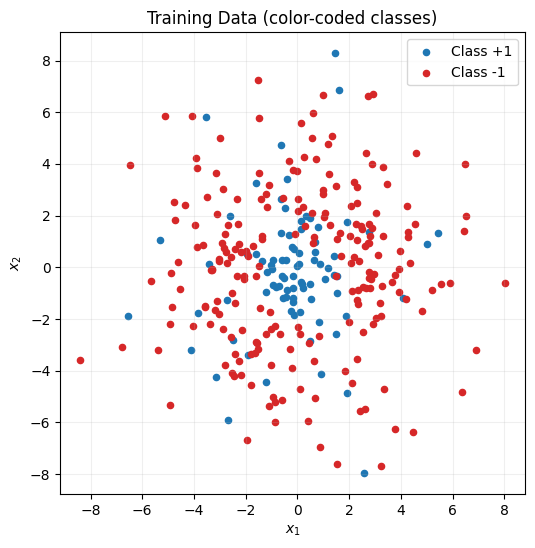

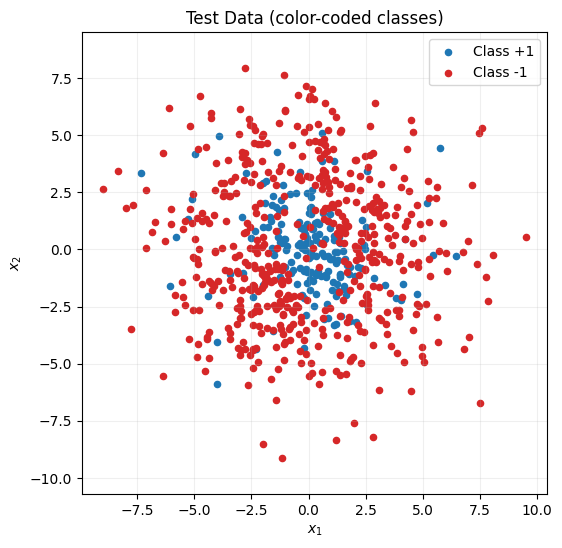

In [2]:
n = 1000
X = 3*np.random.randn(n, 2)

# Elliptical boundary: inside ellipse = +1, outside = -1
ellipse = 2*(X[:,0]**2) + (X[:,1]**2)/1.2 + np.sqrt(2)*(X[:,0]*X[:,1])   # ellipse equation
noise =  1.5*np.random.randn(n)

y = np.sign(5 - ellipse + noise)   # inside ellipse => positive
y[y == 0] = 1

# ---- Lable noise
flip_prob = 0.1
flip = np.random.rand(n) < flip_prob
y[flip] *= -1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42)

def plot_data(X, y, title):
    plt.figure(figsize=(6,6))
    plt.scatter(X[y==1,0],  X[y==1,1],  c='tab:blue',  s=20, label='Class +1')
    plt.scatter(X[y==-1,0], X[y==-1,1], c='tab:red',   s=20, label='Class -1')
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.axis('equal')
    plt.show()

plot_data(X_train, y_train, "Training Data (color-coded classes)")
plot_data(X_test,  y_test,  "Test Data (color-coded classes)")

# Real AdaBoost

In [3]:
def real_adaboost_region(X, y, B=50, max_depth=6, shrinkage=1.0):
    """
    Real AdaBoost (region-wise) using regression trees as weak learners.
    Labels y must be in {-1, +1}.
    """
    
    n = len(y)
    h = np.zeros(n)

    models = []

    for b in range(B):
        # weights
        w = np.exp(-y * h)
        w /= np.sum(w)

        # fit regression tree to targets y with weights
        tree = DecisionTreeRegressor(max_depth=max_depth)
        tree.fit(X, y, sample_weight=w)

        # get leaf indices
        leaf_ids = tree.apply(X)
        unique_leaves = np.unique(leaf_ids)

        # compute gamma per leaf
        gamma = {}

        for leaf in unique_leaves:
            idx = (leaf_ids == leaf)

            w_pos = np.sum(w[idx] * (y[idx] == 1))
            w_neg = np.sum(w[idx] * (y[idx] == -1))

            # avoid division by zero
            w_pos = max(w_pos, 1e-10)
            w_neg = max(w_neg, 1e-10)

            gamma[leaf] = 0.5 * np.log(w_pos / w_neg)

        # update h
        update = np.array([gamma[leaf] for leaf in leaf_ids])
        h += shrinkage * update

        models.append((tree, gamma))

    return models


def predict(models, X, shrinkage=1.0):
    h = np.zeros(X.shape[0])

    for tree, gamma in models:
        leaf_ids = tree.apply(X)
        update = np.array([gamma[leaf] for leaf in leaf_ids])
        h += shrinkage * update

    return np.sign(h)


### Effect of the Number of Boosting Rounds \(B\) on Training and Test Error

We evaluate Real AdaBoost with decision trees (max depth = 8) while varying the 
number of boosting rounds \(B\). For each value of \(B\), we train the model, 
compute the training and test classification error, and identify the value 
\(B^\star\) that minimises the test error. This experiment illustrates the 
role of B as an implicit regularisation factor.

B	Train Error	Test Error
1	0.0267		0.2600
11	0.0000		0.2214
21	0.0000		0.2086
31	0.0000		0.2186
41	0.0000		0.2186
51	0.0000		0.2200
61	0.0000		0.2171
71	0.0000		0.2171
81	0.0000		0.2214
91	0.0000		0.2200
101	0.0000		0.2143
111	0.0000		0.2243
121	0.0000		0.2171
131	0.0000		0.2257
141	0.0000		0.2200
151	0.0000		0.2257
161	0.0000		0.2129
171	0.0000		0.2214
181	0.0000		0.2243
191	0.0000		0.2200
201	0.0000		0.2243
211	0.0000		0.2186
221	0.0000		0.2129
231	0.0000		0.2200
241	0.0000		0.2157
251	0.0000		0.2171
261	0.0000		0.2229
271	0.0000		0.2271
281	0.0000		0.2229
291	0.0000		0.2229

Best B (min test error):
B* = 21
Train error at B*: 0.0000
Test error at B*:  0.2086


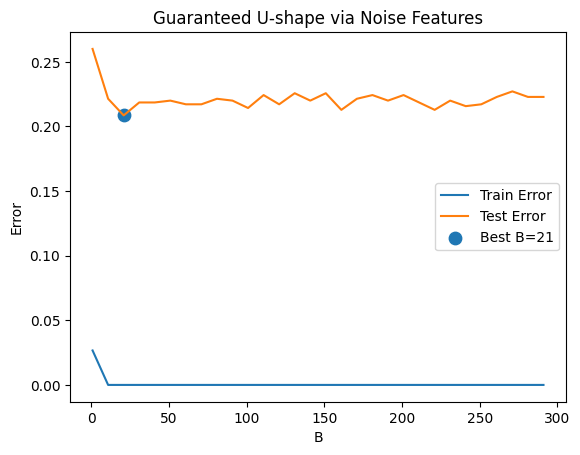

In [4]:
B_values = np.arange(1, 300, 10)

train_err = []
test_err = []

for B in B_values:
    models = real_adaboost_region(X_train, y_train, B=B, max_depth=8)

    y_pred_train = predict(models, X_train)
    y_pred_test = predict(models, X_test)

    train_err.append(np.mean(y_pred_train != y_train))
    test_err.append(np.mean(y_pred_test != y_test))

# --- Convert to arrays for convenience
train_err = np.array(train_err)
test_err = np.array(test_err)

# --- Find optimal B (min test error)
idx_best = np.argmin(test_err)
B_best = B_values[idx_best]
test_err_best = test_err[idx_best]
train_err_best = train_err[idx_best]

# --- Print results nicely
print("B\tTrain Error\tTest Error")
for B, tr, te in zip(B_values, train_err, test_err):
    print(f"{B}\t{tr:.4f}\t\t{te:.4f}")

print("\nBest B (min test error):")
print(f"B* = {B_best}")
print(f"Train error at B*: {train_err_best:.4f}")
print(f"Test error at B*:  {test_err_best:.4f}")

# --- Plot with highlight
plt.figure()
plt.plot(B_values, train_err, label="Train Error")
plt.plot(B_values, test_err, label="Test Error")

# Highlight optimal point
plt.scatter(B_best, test_err_best, s=80, label=f"Best B={B_best}")

plt.xlabel("B")
plt.ylabel("Error")
plt.legend()
plt.title("Guaranteed U-shape via Noise Features")
plt.show()